In [1]:
import pandas as pd

file_path = '/kaggle/input/datasets/sehamhakimothman/asos-weather-data-2019-2026/historical_weather_data_2019_2026.csv'

# Prevents the 'mixed data types' warning for larger files
df = pd.read_csv(file_path, low_memory=False)

df.head()

,station,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,mslp,...,wxcodes,ice_accretion_1hr,ice_accretion_3hr,ice_accretion_6hr,peak_wind_gust,peak_wind_drct,peak_wind_time,feel,metar,snowdepth
0,PIA,2019-01-01 00:00,38.00,36.00,92.42,310.00,8.00,M,M,1005.50,...,-RA,M,M,M,M,M,M,31.50,METAR KPIA 010000Z AUTO 31008KT -RA 03/02 RMK ...,M
1,MLI,2019-01-01 00:00,36.00,34.00,92.35,300.00,10.00,M,M,1006.30,...,-RA,M,M,M,M,M,M,27.98,METAR KMLI 010000Z AUTO 30010KT -RA 02/01 RMK ...,M
2,MVN,2019-01-01 00:03,50.00,44.60,81.61,270.00,12.00,0.00,29.80,M,...,M,M,M,M,M,M,M,44.91,KMVN 010003Z AUTO 27012G21KT 10SM FEW022 BKN02...,M
3,ORD,2019-01-01 00:08,37.00,36.00,96.13,360.00,18.00,0.01,29.56,M,...,-RA BR,M,M,M,26.00,360.00,2019-01-01 00:04,26.33,KORD 010008Z 36018G26KT 5SM -RA BR BKN007 BKN0...,M
4,SPI,2019-01-01 00:10,39.00,39.00,100.00,270.00,14.00,T,29.75,M,...,-RA BR,M,M,M,M,M,M,30.19,KSPI 010010Z 27014KT 6SM -RA BR OVC008 04/04 A...,M


1. **Replace 'M' and 'T' with NaN**

In [2]:
import numpy as np

# 1. COUNT THE HIDDEN CODES
asos_missing_codes = [
    'M', 'T', '$', '////',
    'RVRNO', 'FZNO', 'PWINO', 'TSNO', 
    'PNO', 'SLPNO', 'CHINO', 'VISNO'
]

print("--- Standard Missing Values (NaN) ---")
nan_counts = df.isnull().sum()
print(nan_counts[nan_counts > 0].sort_values(ascending=False))
print("\n" + "="*50 + "\n")

print("--- Specific ASOS Missing/Maintenance Codes ---")
code_total_counts = {}

for code in asos_missing_codes:
    if code in ['CHINO', 'VISNO']:
        count = df.astype(str).apply(lambda x: x.str.contains(code, na=False)).sum().sum()
    else:
        count = (df == code).sum().sum()
        
    code_total_counts[code] = count
    print(f"Code '{code}': {count} occurrences found across the dataset.")

print("\n" + "="*50 + "\n")
print("--- Where are these codes hiding? (Column Breakdown) ---")
for code in asos_missing_codes:
    cols_with_code = []
    for col in df.columns:
        if code in ['CHINO', 'VISNO']:
            match_count = df[col].astype(str).str.contains(code, na=False).sum()
        else:
            match_count = (df[col] == code).sum()
            
        if match_count > 0:
            cols_with_code.append(f"{col} ({match_count} times)")
            
    if cols_with_code:
        print(f"'{code}' appears in: {', '.join(cols_with_code)}")

print("\n" + "="*50 + "\n")

# 2. CLEANING: REPLACE CODES WITH NaN
print("Cleaning data: Converting ASOS codes to standard NaN...")

# Replace exact match codes
exact_matches = [c for c in asos_missing_codes if c not in ['CHINO', 'VISNO']]
df = df.replace(exact_matches, np.nan)

# Replace partial match codes (CHINO / VISNO location strings)
for col in df.columns:
    if df[col].dtype == 'object':
        df.loc[df[col].astype(str).str.contains('CHINO|VISNO', na=False), col] = np.nan

# 3. SAVE: WRITE FINAL CHANGES TO THE OUTPUT FILE
output_path = '/kaggle/working/cleaned_historical_weather_data_2019_2026.csv'
df.to_csv(output_path, index=False)

print(f" SUCCESS: Final changes saved to file!")
print(f"File location: {output_path}")

--- Standard Missing Values (NaN) ---
wxcodes    4
dtype: int64


--- Specific ASOS Missing/Maintenance Codes ---
Code 'M': 133410246 occurrences found across the dataset.
Code 'T': 162504 occurrences found across the dataset.
Code '$': 0 occurrences found across the dataset.
Code '////': 0 occurrences found across the dataset.
Code 'RVRNO': 0 occurrences found across the dataset.
Code 'FZNO': 0 occurrences found across the dataset.
Code 'PWINO': 0 occurrences found across the dataset.
Code 'TSNO': 0 occurrences found across the dataset.
Code 'PNO': 0 occurrences found across the dataset.
Code 'SLPNO': 0 occurrences found across the dataset.
Code 'CHINO': 4373 occurrences found across the dataset.
Code 'VISNO': 2011 occurrences found across the dataset.


--- Where are these codes hiding? (Column Breakdown) ---
'M' appears in: tmpf (65798 times), dwpf (76670 times), relh (76739 times), drct (203221 times), sknt (158218 times), p01i (2394 times), alti (46044 times), mslp (7218900 times)

In [3]:
# ==========================================
# 1. DROP COLUMNS WITH > 80% MISSING VALUES
# ==========================================

# Re-calculate missing percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Re-drop columns with more than 80% missing values, ignoring errors if they are already dropped
cols_to_drop = missing_percentage[missing_percentage > 80].index.tolist()
df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Re-dropped columns: {cols_to_drop}")
print(f"New DataFrame shape after re-dropping: {df.shape}")

# ==========================================
# 2. KAGGLE COMPATIBILITY: SAVE TO OUTPUTS
# ==========================================
output_path = '/kaggle/working/cleaned_historical_weather_data_2019_2026.csv'
df.to_csv(output_path, index=False)

print(f"\n Final changes automatically saved to Kaggle Outputs: {output_path}")

Re-dropped columns: ['mslp', 'gust', 'skyc2', 'skyc3', 'skyc4', 'skyl2', 'skyl3', 'skyl4', 'wxcodes', 'ice_accretion_1hr', 'ice_accretion_3hr', 'ice_accretion_6hr', 'peak_wind_gust', 'peak_wind_drct', 'peak_wind_time', 'snowdepth']
New DataFrame shape after re-dropping: (8555573, 14)

 Final changes automatically saved to Kaggle Outputs: /kaggle/working/cleaned_historical_weather_data_2019_2026.csv


# **CLOUMNS EXPLORATION**

**Unique values in 'station' column**

In [4]:
print("Unique values in 'station' column:")
display(df['station'].unique())

Unique values in 'station' column:


array(['PIA', 'MLI', 'MVN', 'ORD', 'SPI', 'BLV', 'CUL', 'PWK', 'FOA',
       'MQB', 'VYS', 'M30', 'FWC', 'FEP', 'GBG', 'DKB', 'IJX', 'I63',
       'PRG', 'IKK', 'C09', 'AJG', 'IGQ', 'PNT', 'SLO', 'DNV', 'TAZ',
       '3LF', 'PPQ', 'SAR', 'RSV', 'AAA', '1H2', 'HSB', 'RPJ', '06C',
       'LOT', 'TIP', 'ENL', 'OLY', 'C75', 'CIR', 'JOT', 'SFY', 'DEC',
       'MTO', 'MWA', 'DPA', 'ALN', 'MDH', 'ARR', 'CPS', 'LWV', 'CMI',
       'MDW', 'UIN', 'RFD', 'UGN', 'BMI', 'SQI'], dtype=object)

**Normal airport vs. Commercial airport**

             Category  Count  Percentage
0  Commercial-Service     10   16.666667
1      Other Airports     50   83.333333


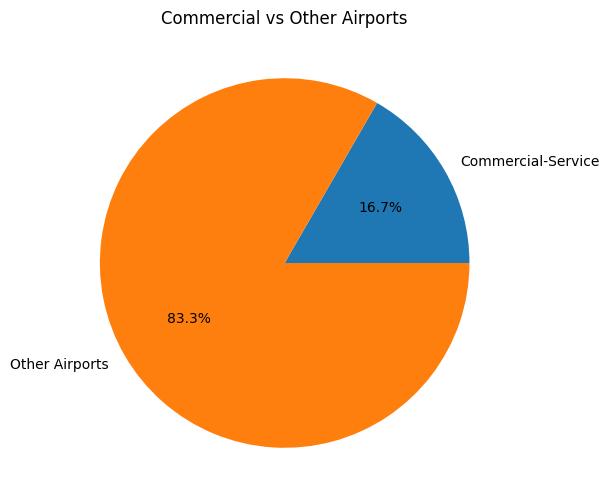

In [5]:
import matplotlib.pyplot as plt

# Airport codes
airport_codes = [
    'PIA', 'MLI', 'MVN', 'ORD', 'SPI', 'BLV', 'CUL', 'PWK', 'FOA',
    'MQB', 'VYS', 'M30', 'FWC', 'FEP', 'GBG', 'DKB', 'IJX', 'I63',
    'PRG', 'IKK', 'C09', 'AJG', 'IGQ', 'PNT', 'SLO', 'DNV', 'TAZ',
    '3LF', 'PPQ', 'SAR', 'RSV', 'AAA', '1H2', 'HSB', 'RPJ', '06C',
    'LOT', 'TIP', 'ENL', 'OLY', 'C75', 'CIR', 'JOT', 'SFY', 'DEC',
    'MTO', 'MWA', 'DPA', 'ALN', 'MDH', 'ARR', 'CPS', 'LWV', 'CMI',
    'MDW', 'UIN', 'RFD', 'UGN', 'BMI', 'SQI'
]

# Airports with scheduled commercial passenger service
commercial_airports = {
    'ORD',  # Chicago O'Hare
    'MDW',  # Chicago Midway
    'PIA',  # Peoria
    'MLI',  # Quad Cities
    'SPI',  # Springfield
    'CMI',  # Champaign
    'BMI',  # Bloomington-Normal
    'UIN',  # Quincy
    'RFD',  # Rockford
    'BLV'   # MidAmerica St. Louis
}
# Count airports
total = len(airport_codes)
commercial_count = sum(code in commercial_airports for code in airport_codes)
other_count = total - commercial_count

# Percentages
commercial_pct = commercial_count / total * 100
other_pct = other_count / total * 100

# Summary table
summary = pd.DataFrame({
    'Category': ['Commercial-Service', 'Other Airports'],
    'Count': [commercial_count, other_count],
    'Percentage': [commercial_pct, other_pct]
})

print(summary)

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    [commercial_count, other_count],
    labels=['Commercial-Service', 'Other Airports'],
    autopct='%1.1f%%'
)
plt.title('Commercial vs Other Airports')
plt.show()

**Valid column ragne**

In [6]:
print(f"Date Range of 'valid' column: {df['valid'].min()} to {df['valid'].max()}")

Date Range of 'valid' column: 2019-01-01 00:00 to 2026-05-03 23:59


**'tmpf' (Temperature in Fahrenheit) Column**

In [7]:
print("Descriptive statistics for 'tmpf' (temperature in Fahrenheit):")
display(df['tmpf'].describe())

Descriptive statistics for 'tmpf' (temperature in Fahrenheit):


count     8489775
unique        763
top         32.00
freq       132029
Name: tmpf, dtype: object

**Checking for Extreme Temperature Values**

In [8]:
# 1. Convert the 'tmpf' column to numeric, forcing non-numeric text into NaN
df['tmpf'] = pd.to_numeric(df['tmpf'], errors='coerce')

# 2. Define your normal temperature range
lower_bound = -80.0
upper_bound = 130.0

# 3. Identify extreme temperature values (NaN values will automatically be ignored here)
extreme_tmpf = df[(df['tmpf'] < lower_bound) | (df['tmpf'] > upper_bound)]

# Count the number of extreme values
extreme_count = len(extreme_tmpf)

# Calculate the percentage of extreme values
total_tmpf_count = df['tmpf'].count() # Count of non-NaN values
extreme_percentage = (extreme_count / total_tmpf_count) * 100 if total_tmpf_count > 0 else 0

print(f"Number of extreme 'tmpf' values (outside {lower_bound}°F to {upper_bound}°F): {extreme_count}")
print(f"Percentage of extreme 'tmpf' values: {extreme_percentage:.2f}%")

if extreme_count > 0:
    print(f"Percentage of extreme 'tmpf' values: {extreme_percentage:.6f}%")
    display(extreme_tmpf.head())

Number of extreme 'tmpf' values (outside -80.0°F to 130.0°F): 15
Percentage of extreme 'tmpf' values: 0.00%
Percentage of extreme 'tmpf' values: 0.000177%


,station,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,vsby,skyc1,skyl1,feel,metar
467363,SFY,2019-05-20 01:17,132.8,NaN,NaN,350.00,5.00,0.00,29.79,10.00,BKN,2300.00,NaN,KSFY 200117Z AUTO 35005G18KT 10SM BKN023 OVC02...
481536,SFY,2019-05-24 05:35,138.2,NaN,NaN,60.00,4.00,0.00,30.07,10.00,CLR,NaN,NaN,KSFY 240535Z AUTO 06004KT 10SM CLR 59/ A3007 R...
483459,SFY,2019-05-24 19:15,145.4,NaN,NaN,120.00,10.00,0.00,29.96,10.00,CLR,NaN,NaN,KSFY 241915Z AUTO 12010KT 10SM CLR 63/ A2996 R...
483540,SFY,2019-05-24 19:54,149.0,NaN,NaN,120.00,10.00,0.00,29.96,10.00,CLR,NaN,NaN,KSFY 241954Z AUTO 12010KT 10SM CLR 65/ A2996 R...
490824,TAZ,2019-05-27 00:57,149.0,NaN,NaN,20.00,3.00,0.00,30.05,10.00,CLR,NaN,NaN,KTAZ 270057Z AUTO 02003KT 10SM CLR 65/ A3005 R...


**DROP Extreme values rows.**

In [9]:
# Get the indices of the extreme temperature rows
extreme_indices = extreme_tmpf.index

# Drop these rows from the original DataFrame `df`
df_cleaned = df.drop(extreme_indices)

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after removing extreme 'tmpf' values: {df_cleaned.shape}")

# Update df to df_cleaned
df = df_cleaned.copy()

print("First 5 rows of the DataFrame after removing extreme temperatures:")
display(df.head())

Original DataFrame shape: (8555573, 14)
DataFrame shape after removing extreme 'tmpf' values: (8555558, 14)
First 5 rows of the DataFrame after removing extreme temperatures:


,station,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,vsby,skyc1,skyl1,feel,metar
0,PIA,2019-01-01 00:00,38.0,36.00,92.42,310.00,8.00,NaN,NaN,NaN,NaN,NaN,31.50,METAR KPIA 010000Z AUTO 31008KT -RA 03/02 RMK ...
1,MLI,2019-01-01 00:00,36.0,34.00,92.35,300.00,10.00,NaN,NaN,NaN,NaN,NaN,27.98,METAR KMLI 010000Z AUTO 30010KT -RA 02/01 RMK ...
2,MVN,2019-01-01 00:03,50.0,44.60,81.61,270.00,12.00,0.00,29.80,10.00,FEW,2200.00,44.91,KMVN 010003Z AUTO 27012G21KT 10SM FEW022 BKN02...
3,ORD,2019-01-01 00:08,37.0,36.00,96.13,360.00,18.00,0.01,29.56,5.00,BKN,700.00,26.33,KORD 010008Z 36018G26KT 5SM -RA BR BKN007 BKN0...
4,SPI,2019-01-01 00:10,39.0,39.00,100.00,270.00,14.00,NaN,29.75,6.00,OVC,800.00,30.19,KSPI 010010Z 27014KT 6SM -RA BR OVC008 04/04 A...


**Distribution of Temperature (tmpf)**

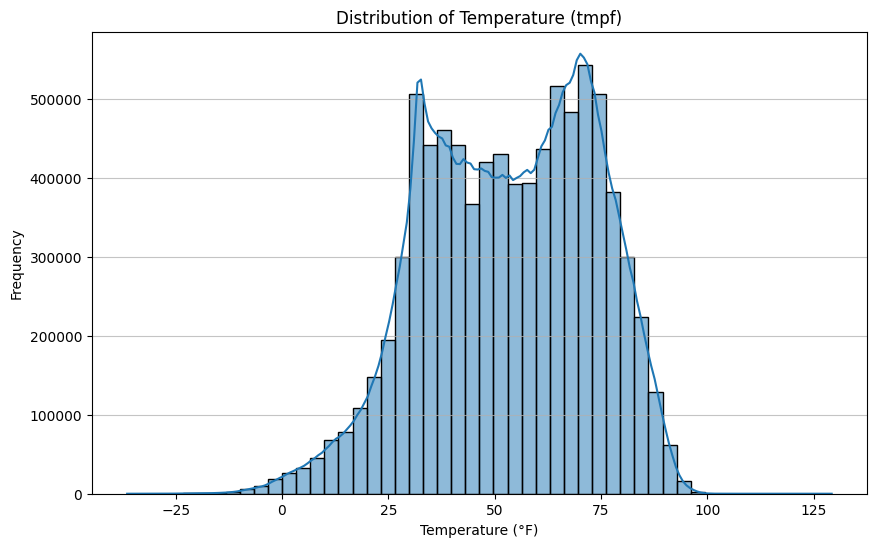

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['tmpf'].dropna(), bins=50, kde=True)
plt.title('Distribution of Temperature (tmpf)')
plt.xlabel('Temperature (°F)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

**Average Temperature by Station**

In [11]:
average_tmpf_by_station = df.groupby('station')['tmpf'].mean().sort_values(ascending=False)

print("Average temperature ('tmpf') by station:")
display(average_tmpf_by_station)

Average temperature ('tmpf') by station:


station
M30    58.599554
CIR    58.226361
ENL    57.677343
SLO    57.502695
MDH    56.817342
SAR    56.753744
AJG    56.716976
HSB    56.579957
CUL    56.473998
MVN    56.293923
CPS    56.181809
BLV    56.123184
OLY    55.981868
LWV    55.954984
FWC    55.724734
PPQ    55.379557
MWA    55.234753
FOA    55.131555
1H2    54.870221
AAA    54.589870
3LF    53.523657
SPI    53.499542
TAZ    53.400058
MTO    53.387052
DEC    53.358647
DNV    53.349291
ALN    53.157700
RSV    53.144158
IJX    53.048904
UIN    52.990146
JOT    52.847230
PIA    52.490522
CMI    52.485142
MDW    52.159704
I63    52.144367
PRG    52.100075
MQB    51.981986
TIP    51.932692
VYS    51.547016
06C    51.540575
IKK    51.538095
BMI    51.494514
PNT    51.363544
MLI    51.348961
C75    51.214635
C09    51.075869
PWK    50.933944
LOT    50.885193
ORD    50.860717
IGQ    50.795260
GBG    50.773119
SQI    49.999885
DPA    49.799405
RPJ    49.712453
RFD    49.563896
SFY    49.521658
ARR    49.100956
DKB    49.082820
UGN   

**DEW POINT COLUMN (dwpf)**

In [12]:
import numpy as np
import pandas as pd

# ========================================================
# FIX: Convert 'dwpf' column to numeric before comparisons
# ========================================================
df['dwpf'] = pd.to_numeric(df['dwpf'], errors='coerce')

# 1. Define the normal dew point temperature range
dwpf_lower_bound = -80.0
dwpf_upper_bound = 86.0

# Identify extreme dew point temperature values
extreme_dwpf = df[(df['dwpf'] < dwpf_lower_bound) | (df['dwpf'] > dwpf_upper_bound)]

# Count the number of extreme values
extreme_dwpf_count = len(extreme_dwpf)

# Calculate the percentage of extreme values
total_dwpf_count = df['dwpf'].count() # Count of non-NaN values
extreme_dwpf_percentage = (extreme_dwpf_count / total_dwpf_count) * 100 if total_dwpf_count > 0 else 0

print(f"Number of extreme 'dwpf' values (outside {dwpf_lower_bound}°F to {dwpf_upper_bound}°F): {extreme_dwpf_count}")
print(f"Percentage of extreme 'dwpf' values: {extreme_dwpf_percentage:.6f}%") 

if extreme_dwpf_count > 0:
    print("\nFirst 5 extreme 'dwpf' values:")
    display(extreme_dwpf.head())

# ========================================================
# CLEAN ANOMALIES AND SAVE TO KAGGLE FILE
# ========================================================
print("\n" + "="*50)
print("Cleaning data: Converting extreme 'dwpf' values to NaN...")

# Replace values outside bounds with NaN directly inside 'df'
df.loc[(df['dwpf'] < dwpf_lower_bound) | (df['dwpf'] > dwpf_upper_bound), 'dwpf'] = np.nan

# Save the freshly cleaned dataset over the output file
output_path = '/kaggle/working/cleaned_historical_weather_data_2019_2026.csv'
df.to_csv(output_path, index=False)

print(f"SUCCESS: Dataset updated and saved to {output_path}")

Number of extreme 'dwpf' values (outside -80.0°F to 86.0°F): 15
Percentage of extreme 'dwpf' values: 0.000177%

First 5 extreme 'dwpf' values:


,station,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,vsby,skyc1,skyl1,feel,metar
582314,BLV,2019-06-23 21:21,96.8,95.0,94.62,300.00,7.00,0.00,29.75,10.00,BKN,1000.00,163.87,KBLV 232121Z AUTO 30007KT 10SM BKN010 36/35 A2...
582819,BLV,2019-06-24 00:56,93.6,92.0,95.44,0.00,0.00,0.00,29.73,10.00,CLR,NaN,146.19,KBLV 240056Z 00000KT 10SM CLR 23/21 A2973 RMK ...
582949,BLV,2019-06-24 01:56,99.7,98.8,97.31,210.00,3.00,0.00,29.74,10.00,FEW,20000.00,187.72,KBLV 240156Z 21003KT 10SM FEW200 23/21 A2974 R...
585722,BLV,2019-06-24 21:56,120.7,100.0,54.67,270.00,9.00,0.00,29.75,10.00,SCT,4900.00,212.58,KBLV 242156Z 27009G16KT 10SM SCT049 SCT060 28/...
585858,BLV,2019-06-24 22:56,120.2,96.3,49.68,290.00,11.00,0.00,29.77,10.00,CLR,NaN,195.62,KBLV 242256Z 29011G19KT 10SM CLR 27/16 A2977 R...



Cleaning data: Converting extreme 'dwpf' values to NaN...
SUCCESS: Dataset updated and saved to /kaggle/working/cleaned_historical_weather_data_2019_2026.csv


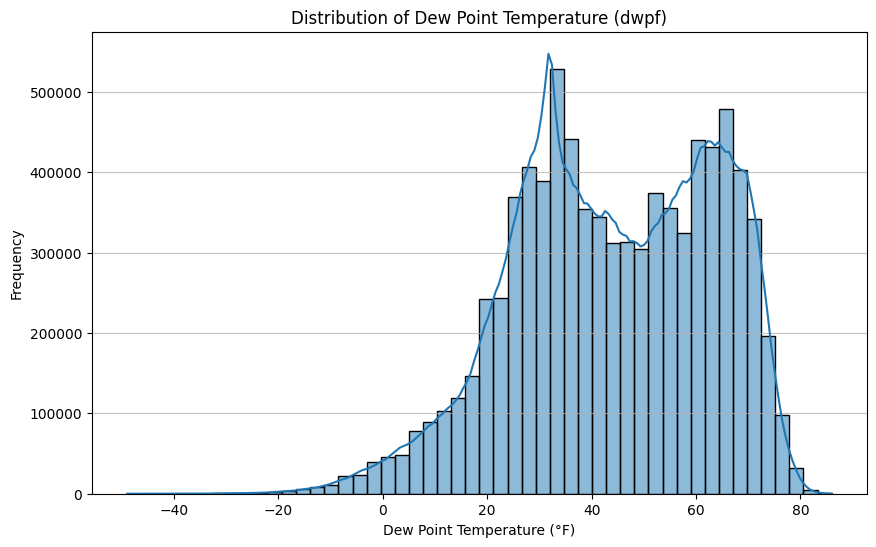

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['dwpf'].dropna(), bins=50, kde=True)
plt.title('Distribution of Dew Point Temperature (dwpf)')
plt.xlabel('Dew Point Temperature (°F)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

**Relative Humidity Values ('relh') COLUMN**

In [14]:
##

**Wind Direction "drct" Column**

In [15]:
import numpy as np
import pandas as pd

# 1. Define the valid boundaries for wind direction
drct_lower_bound = 0.0
drct_upper_bound = 360.0

# Ensure the column is fully numeric for boundary checks
df['drct'] = pd.to_numeric(df['drct'], errors='coerce')

# 2. Identify extreme/out-of-bounds degree values
extreme_drct = df[(df['drct'] < drct_lower_bound) | (df['drct'] > drct_upper_bound)]
extreme_drct_count = len(extreme_drct)

# Calculate percentage of anomalies
total_drct_count = df['drct'].count()
extreme_drct_percentage = (extreme_drct_count / total_drct_count) * 100 if total_drct_count > 0 else 0

print(f"Number of extreme 'drct' values (outside {drct_lower_bound}° to {drct_upper_bound}°): {extreme_drct_count}")
print(f"Percentage of extreme 'drct' values: {extreme_drct_percentage:.6f}%")

# ========================================================
# CONDITIONALLY CLEAN ANOMALIES AND SAVE TO KAGGLE FILE
# ========================================================
if extreme_drct_count > 0:
    print("\nFirst 5 extreme 'drct' values:")
    display(extreme_drct.head())
    
    print("\n" + "="*50)
    print("Cleaning data: Converting extreme 'drct' values to NaN...")
    
    # Replace values outside bounds with NaN directly inside 'df'
    df.loc[(df['drct'] < drct_lower_bound) | (df['drct'] > drct_upper_bound), 'drct'] = np.nan
    
    # Save the freshly cleaned dataset over the output file
    output_path = '/kaggle/working/cleaned_historical_weather_data_2019_2026.csv'
    df.to_csv(output_path, index=False)
    print(f" SUCCESS: Dataset updated and saved to {output_path}")

else:
    print("\n" + "="*50)
    print(" Everything is clean! No extreme values found, skipping the save file step.")

Number of extreme 'drct' values (outside 0.0° to 360.0°): 0
Percentage of extreme 'drct' values: 0.000000%

 Everything is clean! No extreme values found, skipping the save file step.


**Wind Speed in knots "sknt" Column**

In [16]:
# 1. Define the valid boundaries for wind speed
sknt_lower_bound = 0.0
sknt_upper_bound = 125.0

# Ensure the column is fully numeric for boundary checks
df['sknt'] = pd.to_numeric(df['sknt'], errors='coerce')

# 2. Identify extreme/out-of-bounds wind speed values
extreme_sknt = df[(df['sknt'] < sknt_lower_bound) | (df['sknt'] > sknt_upper_bound)]
extreme_sknt_count = len(extreme_sknt)

# Calculate percentage of anomalies
total_sknt_count = df['sknt'].count()
extreme_sknt_percentage = (extreme_sknt_count / total_sknt_count) * 100 if total_sknt_count > 0 else 0

print(f"Number of extreme 'sknt' values (outside {sknt_lower_bound} to {sknt_upper_bound} knots): {extreme_sknt_count}")
print(f"Percentage of extreme 'sknt' values: {extreme_sknt_percentage:.6f}%")

# ========================================================
# CONDITIONALLY CLEAN ANOMALIES AND SAVE TO KAGGLE FILE
# ========================================================
if extreme_sknt_count > 0:
    print("\nFirst 5 extreme 'sknt' values:")
    display(extreme_sknt.head())
    
    print("\n" + "="*50)
    print("Cleaning data: Converting extreme 'sknt' values to NaN...")
    
    # Replace values outside bounds with NaN directly inside 'df'
    df.loc[(df['sknt'] < sknt_lower_bound) | (df['sknt'] > sknt_upper_bound), 'sknt'] = np.nan
    
    # Save the freshly cleaned dataset over the output file
    output_path = '/kaggle/working/cleaned_historical_weather_data_2019_2026.csv'
    df.to_csv(output_path, index=False)
    print(f"SUCCESS: Dataset updated and saved to {output_path}")

else:
    print("\n" + "="*50)
    print("Everything is clean! No extreme values found, skipping the save file step.")

Number of extreme 'sknt' values (outside 0.0 to 125.0 knots): 5
Percentage of extreme 'sknt' values: 0.000060%

First 5 extreme 'sknt' values:


,station,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,vsby,skyc1,skyl1,feel,metar
3786971,SPI,2022-02-19 02:47,34.0,21.0,58.56,220.0,136.0,0.00,30.06,10.00,CLR,NaN,9.21,KSPI 190247Z 220136KT 10SM CLR 01/M06 A3006 RM...
4325443,DEC,2022-08-03 17:54,90.0,80.0,72.79,200.0,165.0,0.00,29.89,10.00,FEW,2600.00,107.87,KDEC 031754Z COR 200165KT 10SM FEW026 32/27 A2...
7381409,LOT,2025-04-11 14:55,46.4,32.0,57.00,0.0,208.0,0.00,30.27,10.00,CLR,NaN,26.31,KLOT 111455Z 0208G13KT 10SM CLR 08/M00 A3027
7448830,LOT,2025-05-03 20:45,57.2,41.0,54.60,0.0,216.0,0.00,29.97,10.00,CLR,NaN,57.20,KLOT 032045Z 0216G21KT 10SM CLR 14/05 A2997
8313261,SPI,2026-02-15 12:52,39.2,39.2,100.00,0.0,206.0,0.00,29.96,1.50,OVC,200.00,14.50,KSPI 151252Z AUTO 0206KT 1 1/2SM OVC002 04/04 ...



Cleaning data: Converting extreme 'sknt' values to NaN...
SUCCESS: Dataset updated and saved to /kaggle/working/cleaned_historical_weather_data_2019_2026.csv


**p01i Cloumn (1-Hour Precipitation in inches)**

In [17]:
# 1. Define the valid boundaries for 1-hour precipitation
p01i_lower_bound = 0.00
p01i_upper_bound = 10.00

# 2. Check for and handle the 'P0000' Trace string if it exists
trace_count = 0
if df['p01i'].dtype == 'object':
    trace_count = (df['p01i'] == 'P0000').sum()
    print(f"Number of 'P0000' (Trace precipitation) string flags found: {trace_count}")
    # Convert trace to 0.0 so it remains numeric and valid
    df['p01i'] = df['p01i'].replace('P0000', 0.0)

# Ensure the column is fully numeric for boundary checks
df['p01i'] = pd.to_numeric(df['p01i'], errors='coerce')

# 3. Identify extreme/out-of-bounds precipitation values
extreme_p01i = df[(df['p01i'] < p01i_lower_bound) | (df['p01i'] > p01i_upper_bound)]
extreme_p01i_count = len(extreme_p01i)

# Calculate percentage of anomalies
total_p01i_count = df['p01i'].count()
extreme_p01i_percentage = (extreme_p01i_count / total_p01i_count) * 100 if total_p01i_count > 0 else 0

print(f"Number of extreme 'p01i' values (outside {p01i_lower_bound} to {p01i_upper_bound} inches): {extreme_p01i_count}")
print(f"Percentage of extreme 'p01i' values: {extreme_p01i_percentage:.6f}%")
# ========================================================
# CONDITIONALLY CLEAN ANOMALIES AND SAVE TO KAGGLE FILE
# ========================================================
if extreme_p01i_count > 0:
    print("\nFirst 5 extreme 'p01i' values:")
    display(extreme_p01i.head())
    
    print("\n" + "="*50)
    print("Cleaning data: Converting extreme 'p01i' values to NaN...")
    
    # Replace values outside bounds with NaN directly inside 'df'
    df.loc[(df['p01i'] < p01i_lower_bound) | (df['p01i'] > p01i_upper_bound), 'p01i'] = np.nan
    
    # Save the freshly cleaned dataset over the output file
    output_path = '/kaggle/working/cleaned_historical_weather_data_2019_2026.csv'
    df.to_csv(output_path, index=False)
    print(f"SUCCESS: Dataset updated and saved to {output_path}")

else:
    print("\n" + "="*50)
    print("Everything is clean! No extreme precipitation values found, skipping the save file step.")

Number of 'P0000' (Trace precipitation) string flags found: 0
Number of extreme 'p01i' values (outside 0.0 to 10.0 inches): 1
Percentage of extreme 'p01i' values: 0.000012%

First 5 extreme 'p01i' values:


,station,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,vsby,skyc1,skyl1,feel,metar
4054778,BLV,2022-05-11 19:56,90.3,76.5,64.03,140.0,4.0,13.2,30.05,9.00,SCT,3800.00,102.85,KBLV 111956Z 14004KT 9SM SCT038 32/25 A3005 RM...



Cleaning data: Converting extreme 'p01i' values to NaN...
SUCCESS: Dataset updated and saved to /kaggle/working/cleaned_historical_weather_data_2019_2026.csv


**alti Column Pressure altimeter in inches**

In [18]:
# 1. Define the valid boundaries for pressure altimeter
alti_lower_bound = 16.9
alti_upper_bound = 31.5

# Ensure the column is fully numeric for boundary checks
df['alti'] = pd.to_numeric(df['alti'], errors='coerce')

# 2. Identify extreme/out-of-bounds altimeter values
extreme_alti = df[(df['alti'] < alti_lower_bound) | (df['alti'] > alti_upper_bound)]
extreme_alti_count = len(extreme_alti)

# Calculate percentage of anomalies
total_alti_count = df['alti'].count()
extreme_alti_percentage = (extreme_alti_count / total_alti_count) * 100 if total_alti_count > 0 else 0

print(f"Number of extreme 'alti' values (outside {alti_lower_bound} to {alti_upper_bound} inHg): {extreme_alti_count}")
print(f"Percentage of extreme 'alti' values: {extreme_alti_percentage:.6f}%")

# ========================================================
# CONDITIONALLY CLEAN ANOMALIES AND SAVE TO KAGGLE FILE
# ========================================================
if extreme_alti_count > 0:
    print("\nFirst 5 extreme 'alti' values:")
    display(extreme_alti.head())
    
    print("\n" + "="*50)
    print("Cleaning data: Converting extreme 'alti' values to NaN...")
    
    # Replace values outside bounds with NaN directly inside 'df'
    df.loc[(df['alti'] < alti_lower_bound) | (df['alti'] > alti_upper_bound), 'alti'] = np.nan
    
    # Save the freshly cleaned dataset over the output file
    output_path = '/kaggle/working/cleaned_historical_weather_data_2019_2026.csv'
    df.to_csv(output_path, index=False)
    print(f"SUCCESS: Dataset updated and saved to {output_path}")

else:
    print("\n" + "="*50)
    print("Everything is clean! No extreme altimeter values found, skipping the save file step.")

Number of extreme 'alti' values (outside 16.9 to 31.5 inHg): 13
Percentage of extreme 'alti' values: 0.000153%

First 5 extreme 'alti' values:


,station,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,vsby,skyc1,skyl1,feel,metar
939501,ALN,2019-10-10 21:50,68.0,68.0,100.00,140.0,5.0,0.0,39.91,3.00,SCT,3700.00,68.00,KALN 102150Z 14005KT 3SM RA SCT037 BKN075 BKN0...
1291408,BLV,2020-01-23 19:56,33.8,33.8,100.00,120.0,6.0,0.0,32.00,10.00,FEW,500.00,27.70,KBLV 231956Z 12006KT 10SM -RA FEW005 OVC012 01...
1896703,ALN,2020-07-22 15:49,78.8,75.2,88.75,0.0,0.0,0.0,60.02,10.00,BKN,2100.00,78.80,KALN 221549Z 00000KT 10SM BKN021 26/24 A6002
1960538,DKB,2020-08-11 03:15,NaN,NaN,NaN,NaN,NaN,0.0,9.30,NaN,NaN,NaN,NaN,KDKB 110315 973 UAUS31 KWBC 110324 ARP UAL393 ...
3603299,MWA,2021-12-24 20:45,60.8,55.4,82.37,200.0,15.0,0.0,2.96,10.00,OVC,1500.00,60.80,KMWA 242045Z 20015G26KT 10SM OVC015 16/13 A0296



Cleaning data: Converting extreme 'alti' values to NaN...
SUCCESS: Dataset updated and saved to /kaggle/working/cleaned_historical_weather_data_2019_2026.csv


In [19]:
df.head()

,station,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,vsby,skyc1,skyl1,feel,metar
0,PIA,2019-01-01 00:00,38.0,36.0,92.42,310.0,8.0,NaN,NaN,NaN,NaN,NaN,31.50,METAR KPIA 010000Z AUTO 31008KT -RA 03/02 RMK ...
1,MLI,2019-01-01 00:00,36.0,34.0,92.35,300.0,10.0,NaN,NaN,NaN,NaN,NaN,27.98,METAR KMLI 010000Z AUTO 30010KT -RA 02/01 RMK ...
2,MVN,2019-01-01 00:03,50.0,44.6,81.61,270.0,12.0,0.00,29.80,10.00,FEW,2200.00,44.91,KMVN 010003Z AUTO 27012G21KT 10SM FEW022 BKN02...
3,ORD,2019-01-01 00:08,37.0,36.0,96.13,360.0,18.0,0.01,29.56,5.00,BKN,700.00,26.33,KORD 010008Z 36018G26KT 5SM -RA BR BKN007 BKN0...
4,SPI,2019-01-01 00:10,39.0,39.0,100.00,270.0,14.0,NaN,29.75,6.00,OVC,800.00,30.19,KSPI 010010Z 27014KT 6SM -RA BR OVC008 04/04 A...
